In [1]:
!pip install matplotlib deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 20.2 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [3]:
# Define the number of locations and vehicles
num_locations = 20
locations = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(num_locations)]
depot = (50, 50)
num_vehicles = 3

In [4]:
# Genetic Algorithm Setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMin)

In [5]:
# Set up the individuals and population
toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(num_locations), num_locations)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [6]:
# Fitness Function
def evalVRP(individual):
    total_dist = 0
    distances = []
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        dist = sum(np.linalg.norm(np.array(vehicle_route[j]) - np.array(vehicle_route[j+1])) for j in range(len(vehicle_route)-1))
        distances.append(dist)
        total_dist += dist
    total_dist = sum(distances)
    std_dev = np.std(distances)
    return (total_dist, std_dev)

toolbox.register("evaluate", evalVRP)

In [7]:
# Genetic Operators
toolbox.register("mate", tools.cxPartialyMatched)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

In [8]:
def plot_routes(individual, title="Routes"):
    plt.figure()
    for (x, y) in locations:
        plt.plot(x, y, 'bo')
    plt.plot(depot[0], depot[1], 'rs')

    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]

        plt.plot(*zip(*vehicle_route), marker='o', label=f'Vehicle {i + 1}')

    plt.title(title)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.legend()
    plt.show()

gen	nevals	avg    	min    
0  	300   	616.299	7.36617
1  	213   	590.894	3.73594
2  	243   	577.707	2.14539
3  	232   	569.502	5.79838
4  	233   	563.803	3.26464
5  	218   	555.574	3.26464
6  	213   	543.422	4.43878
7  	233   	542.622	6.8708 
8  	219   	529.158	3.5131 
9  	209   	523.345	4.88503
10 	224   	514.695	7.43886
11 	230   	516.675	6.21829
12 	230   	511.098	6.82698
13 	217   	488.863	3.60926
14 	231   	491.73 	1.45253
15 	250   	480.118	1.45253
16 	238   	474.938	3.01335
17 	236   	459.783	4.16552
18 	225   	437.081	0.344396
19 	225   	412.584	0.344396
20 	209   	395.155	5.61761 
21 	232   	390.424	3.3662  
22 	237   	382.61 	5.34601 
23 	217   	379.557	7.56513 
24 	227   	371.04 	8.18953 
25 	246   	369.007	7.95694 
26 	233   	354.973	2.00723 
27 	219   	347.819	2.18375 
28 	229   	343.124	9.29984 
29 	223   	339.19 	4.79943 
30 	238   	343.44 	1.51465 
31 	225   	338.53 	18.6065 
32 	221   	336.425	1.60739 
33 	243   	329.639	6.43614 
34 	232   	326.877	11.6213 
35 	244   	

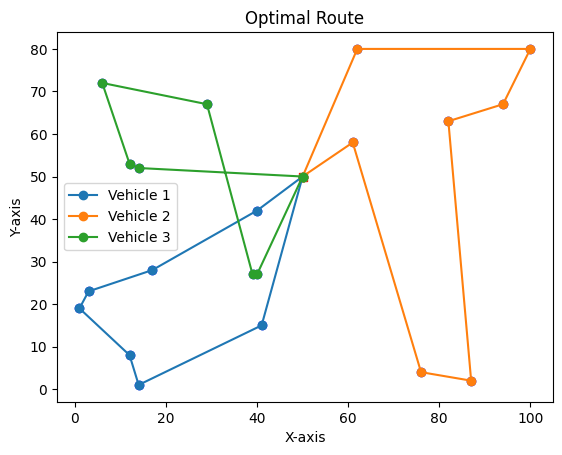

In [9]:
# Run the Genetic Algorithm
def main():
    random.seed(42)
    pop = toolbox.population(n=300)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    algorithms.eaSimple(pop, toolbox, 0.7, 0.2, 300, stats=stats, halloffame=hof)

    plot_routes(hof[0], "Optimal Route")
    return pop, stats, hof

if __name__ == "__main__":
    main()

In [10]:
import time

# Precompute distance matrix
all_points = [depot] + locations
pts = np.array(all_points)
dist_matrix = np.sqrt(((pts[:, None] - pts[None, :]) ** 2).sum(axis=-1))

# New fitness using matrix lookups
def evalVRP_fast(individual):
    distances = []
    for i in range(num_vehicles):
        route = [0] + [individual[j] + 1 for j in range(i, len(individual), num_vehicles)] + [0]
        dist = sum(dist_matrix[route[k], route[k+1]] for k in range(len(route) - 1))
        distances.append(dist)
    return (sum(distances), np.std(distances))

sample = toolbox.individual()
N = 10000

t0 = time.perf_counter()
for _ in range(N): evalVRP(sample)
old_ms = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
for _ in range(N): evalVRP_fast(sample)
new_ms = (time.perf_counter() - t0) * 1000

print(f"Original : {old_ms:.1f} ms  ({old_ms/N*1000:.2f} µs/call)")
print(f"Optimized: {new_ms:.1f} ms  ({new_ms/N*1000:.2f} µs/call)")
print(f"Speedup  : {old_ms/new_ms:.1f}×")

Original : 2313.5 ms  (231.35 µs/call)
Optimized: 369.9 ms  (36.99 µs/call)
Speedup  : 6.3×
